# 08 · 从 Router 到 ReAct、Plan-and-Execute

- **Router → ReAct：**沿用 06 的业务场景，TEU 计算改为 ReAct 工具循环，规则预审保留为普通 Graph 节点。
- **ReAct：**真实 LLM 自主调用 `calculate_teu`；有 tool call 就执行并回到 Agent，无 tool call 即结束。
- **Plan-and-Execute：**真实 LLM Planner 生成结构化计划，Worker 执行，真实 LLM Evaluator 决定结束或有限次数 Replan。

第 39 页并排展示 06 Router 与本节 ReAct 的 Graph，用于直接对比两种编排方式。两条可执行链路都使用 `.env` 配置的真实模型。

In [14]:
# Router / ReAct Graph 对比展示辅助函数
from base64 import b64encode

from IPython.display import HTML, Markdown, display


def display_graph_comparison(left_graph, right_graph) -> None:
    '''将两张 Graph 并排放在同一页；PNG 不可用时回退到 Mermaid。'''
    display(Markdown("## 第 39 页 · Router 与 ReAct Graph 对比"))
    try:
        cards = []
        for title, graph in (("06 · Router", left_graph), ("08 · ReAct", right_graph)):
            encoded = b64encode(graph.get_graph().draw_mermaid_png()).decode("ascii")
            cards.append(
                f'<section style="flex:1;min-width:0;text-align:center">'
                f'<h3>{title}</h3>'
                f'<img src="data:image/png;base64,{encoded}" style="max-width:100%;height:auto" />'
                '</section>'
            )
        display(HTML('<div style="display:flex;gap:24px;align-items:flex-start">' + ''.join(cards) + '</div>'))
    except Exception as exc:
        print("PNG 不可用，回退到 Mermaid：", exc)
        for title, graph in (("06 · Router", left_graph), ("08 · ReAct", right_graph)):
            display(Markdown(f"### {title}\n```mermaid\n{graph.get_graph().draw_mermaid()}\n```"))

In [15]:
from __future__ import annotations

from pathlib import Path
import os

from dotenv import load_dotenv


def find_repo_root() -> Path:
    '''向上找到含 pyproject.toml 的仓库根，避免 notebook 工作目录不在根上。'''
    here = Path.cwd()
    for p in [here, *here.parents]:
        if (p / "pyproject.toml").exists():
            return p
    return here


ROOT = find_repo_root()
os.chdir(ROOT)
load_dotenv(ROOT / ".env")
missing_llm = [
    name for name in ("LLM_BASE_URL", "LLM_MODEL")
    if not (os.getenv(name) or "").strip()
]
if missing_llm:
    raise ValueError(
        "真实 LLM ReAct/Plan-and-Execute 必须配置 .env，缺少："
        + ", ".join(missing_llm)
    )
print("cwd =", ROOT)
print("mode = live LLM required")

cwd = /Users/kunwei/Projects/oocl-agent-workshop-lab/oocl-2026-ai-agent-training
mode = live LLM required


In [16]:
def show_graph(graph):
    """在 Notebook 中展示 State / Node / Edge。"""
    from IPython.display import Image, display

    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception as exc:
        print("PNG 不可用，打印 Mermaid：", exc)
        print(graph.get_graph().draw_mermaid())


mode = live LLM ReAct trace


## 第 39 页 · Router 与 ReAct Graph 对比


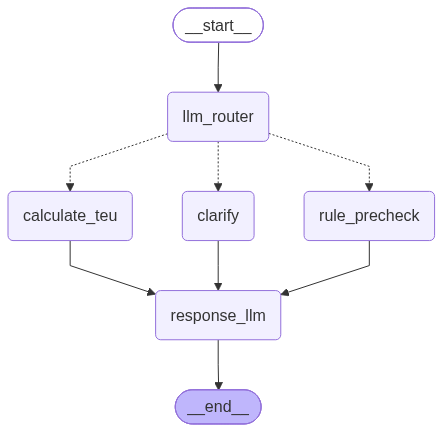
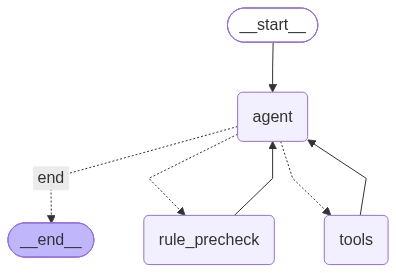

In [17]:
import re
from typing import Annotated, Literal, TypedDict

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.tools import tool
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from pydantic import BaseModel, Field

from hello_agent.config import get_llm


TEU_PER_EQUIPMENT = {"20GP": 1, "40GP": 2, "40HQ": 2}


@tool
def calculate_teu(equipment: str, quantity: int) -> int:
    '''按课堂约定换算 TEU。支持 20GP、40GP、40HQ。'''
    key = equipment.strip().upper()
    if key not in TEU_PER_EQUIPMENT:
        raise ValueError(f"不支持的箱型: {equipment}")
    if quantity < 0:
        raise ValueError("quantity 不能为负数")
    return TEU_PER_EQUIPMENT[key] * quantity


def rule_precheck_node(state: "ReActState") -> dict:
    '''普通 Graph 节点：执行规则预审，不通过 ToolNode。'''
    result = {
        "booking_id": state["booking_id"],
        "decision": "manual_review_required",
        "checks": ["equipment", "route", "dangerous_goods"],
        "mock": True,
    }
    return {"business_result": result}


class ReActState(TypedDict, total=False):
    messages: Annotated[list, add_messages]
    next_step: Literal["tools", "rule_precheck", "end"]
    booking_id: str
    business_result: dict


class AgentDecision(BaseModel):
    '''Agent 在执行业务前自主选择下一步。'''
    action: Literal["calculate_teu", "rule_precheck", "respond"]
    booking_id: str | None = Field(default=None, description="规则预审的订舱 ID")
    response: str | None = Field(default=None, description="需要澄清或直接回答时的内容")


base_llm = get_llm(temperature=0)
react_tools = [calculate_teu]
react_llm = base_llm.bind_tools(react_tools)
decision_parser = PydanticOutputParser(pydantic_object=AgentDecision)


def decide(state: ReActState) -> dict:
    node_result = state.get("business_result")
    if node_result:
        response = base_llm.invoke([
            SystemMessage(content="你是订舱业务 Agent。请根据规则预审节点结果给出简洁终答。"),
            *state["messages"],
            SystemMessage(content=f"规则预审节点结果：{node_result}"),
        ])
        return {"messages": [response], "next_step": "end"}

    if isinstance(state["messages"][-1], ToolMessage):
        response = react_llm.invoke([
            SystemMessage(content="根据 ToolMessage 的计算结果给出简洁终答，不要再调用工具。"),
            *state["messages"],
        ])
        return {"messages": [response], "next_step": "end"}

    decision_message = base_llm.invoke([
        SystemMessage(content=(
            "你是订舱业务 Agent。请选择下一步：TEU 计算选 calculate_teu；"
            "规则预审选 rule_precheck 并提取 booking_id；"
            "参数不足或其他问题选 respond，在 response 中提问或回答。"
            "不得猜测参数，不得输出 JSON 以外的内容。\n"
            + decision_parser.get_format_instructions()
        )),
        *state["messages"],
    ])
    json_match = re.search(r"\{.*\}", str(decision_message.content), re.DOTALL)
    if not json_match:
        raise ValueError(f"Agent 未返回可解析的决策 JSON: {decision_message.content}")
    decision = AgentDecision.model_validate_json(json_match.group(0))
    if decision.action == "rule_precheck":
        if not decision.booking_id:
            return {
                "messages": [AIMessage(content="请补充需要预审的订舱 ID。")],
                "next_step": "end",
            }
        return {"booking_id": decision.booking_id, "next_step": "rule_precheck"}
    if decision.action == "respond":
        return {
            "messages": [AIMessage(content=decision.response or "请补充具体业务需求。")],
            "next_step": "end",
        }

    response = react_llm.invoke([
        SystemMessage(content=(
            "你是订舱业务 Agent。用户要求计算 TEU 时调用 calculate_teu。"
            "参数不足时直接提问澄清，不得猜测参数。"
            "此轮必须调用 calculate_teu。"
        )),
        *state["messages"],
    ])
    next_step = "tools" if getattr(response, "tool_calls", None) else "end"
    return {"messages": [response], "next_step": next_step}


def route(state: ReActState) -> Literal["tools", "rule_precheck", "end"]:
    return state["next_step"]


react_builder = StateGraph(ReActState)
react_builder.add_node("agent", decide)
react_builder.add_node("tools", ToolNode(react_tools))
react_builder.add_node("rule_precheck", rule_precheck_node)
react_builder.add_edge(START, "agent")
react_builder.add_conditional_edges(
    "agent",
    route,
    {"tools": "tools", "rule_precheck": "rule_precheck", "end": END},
)
react_builder.add_edge("tools", "agent")
react_builder.add_edge("rule_precheck", "agent")
react_graph = react_builder.compile()
print("mode = live LLM ReAct trace")


# 仅用于第 39 页的结构对比：抽取 06-router 的节点和边，不重复其业务实现。
def _noop(_: ReActState) -> dict:
    return {}


def _router_path(_: ReActState) -> Literal["calculate_teu", "rule_precheck", "clarify"]:
    return "clarify"


router_builder = StateGraph(ReActState)
for node_name in ("llm_router", "calculate_teu", "rule_precheck", "clarify", "response_llm"):
    router_builder.add_node(node_name, _noop)
router_builder.add_edge(START, "llm_router")
router_builder.add_conditional_edges(
    "llm_router",
    _router_path,
    {name: name for name in ("calculate_teu", "rule_precheck", "clarify")},
)
for node_name in ("calculate_teu", "rule_precheck", "clarify"):
    router_builder.add_edge(node_name, "response_llm")
router_builder.add_edge("response_llm", END)
router_graph = router_builder.compile()


display_graph_comparison(router_graph, react_graph)

In [ ]:
result = react_graph.invoke(
    {"messages": [{"role": "user", "content": "请计算 2×40HQ 的 TEU"}]},
    {"recursion_limit": 6},
)
for message in result["messages"]:
    print(type(message).__name__, ":", getattr(message, "content", "")[:200])

tool_messages = [message for message in result["messages"] if isinstance(message, ToolMessage)]
final_answer = result["messages"][-1]
assert tool_messages, "真实模型未产生 ToolMessage"
assert tool_messages[-1].name == "calculate_teu"
assert str(tool_messages[-1].content).strip() == "4"
assert not getattr(final_answer, "tool_calls", None)
assert str(getattr(final_answer, "content", "")).strip()
print("PASS: ReAct 自主选择 calculate_teu，并根据 Observation 生成终答")

precheck_result = react_graph.invoke(
    {"messages": [{"role": "user", "content": "请预审订舱 BK-DEMO-006 的适用规则"}]},
    {"recursion_limit": 6},
)
assert precheck_result["business_result"]["booking_id"] == "BK-DEMO-006"
assert precheck_result["business_result"]["mock"] is True
assert not any(isinstance(message, ToolMessage) for message in precheck_result["messages"])
print("PASS: rule_precheck 由普通节点执行，未产生 ToolMessage")

## Plan-and-Execute 结构

Planner 产出任务列表 → `Send` 并行 Worker → Evaluator 审核 → 可选 Replan（本例最多一次）→ Finalizer。下一节给出完整真实 LLM 实现。

In [ ]:
print("Goal → LLM Planner → Send Workers → LLM Evaluator → Result")
print("           ↑________ Command Replan (max 1) ________↓")

<!-- codex:p0:08 -->
## P0 进阶 · 可运行的 Plan-and-Execute

下面把前面的结构示意升级成一张由真实 LLM 驱动的图：

1. 真实 LLM Planner 通过结构化输出生成本轮任务；
2. 条件边返回多个 `Send`，动态并行创建 Worker；
3. reducer 汇总 Worker 证据；
4. 真实 LLM Evaluator 审核证据，并返回 `Command(update=..., goto=...)` 选择 Replan 或结束；
5. `replan_count` 与 `recursion_limit` 共同限制循环。

In [ ]:
import operator

from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
from langgraph.types import Command, Send


TaskName = Literal["equipment", "route", "dangerous_goods"]


class BookingPlan(BaseModel):
    tasks: list[TaskName] = Field(description="本轮需要执行的审核任务")


class EvidenceEvaluation(BaseModel):
    approved: bool = Field(description="证据是否覆盖全部三个审核维度")
    feedback: str = Field(description="对证据完整性的简短说明")


planner_parser = PydanticOutputParser(pydantic_object=BookingPlan)
evaluator_parser = PydanticOutputParser(pydantic_object=EvidenceEvaluation)


class PlanState(TypedDict, total=False):
    booking_id: str
    tasks: list[str]
    evidence: Annotated[list[str], operator.add]
    replan_count: int
    evaluation: str
    result: str


class WorkerState(TypedDict):
    task: str


def planner(state: PlanState) -> dict:
    replan_count = state.get("replan_count", 0)
    if replan_count == 0:
        instruction = (
            "这是首轮教学计划。必须且只能选择 equipment 和 route，"
            "故意暂不选择 dangerous_goods，以便下一轮演示 Replan。"
        )
    else:
        instruction = (
            "这是唯一一次 Replan。已有 evidence 如下："
            f"{state.get('evidence', [])}。必须且只能选择尚缺的 dangerous_goods。"
        )
    plan_message = base_llm.invoke(
        [
            SystemMessage(content=(
                "你是订舱预审 Planner。严格按照用户给出的本轮约束输出 JSON；"
                "不得添加枚举外任务，不得输出解释。\n"
                + planner_parser.get_format_instructions()
            )),
            HumanMessage(content=f"booking_id={state['booking_id']}。{instruction}"),
        ]
    )
    plan = planner_parser.invoke(plan_message)
    tasks = list(dict.fromkeys(plan.tasks))
    if not tasks:
        raise ValueError("真实 LLM Planner 未返回任何任务")
    print("LLM plan =", tasks)
    return {"tasks": tasks}


def dispatch_workers(state: PlanState):
    return [Send("worker", {"task": task}) for task in state["tasks"]]


def worker(state: WorkerState) -> dict:
    evidence_by_task = {
        "equipment": "equipment:ok",
        "route": "route:ok",
        "dangerous_goods": "dangerous_goods:manual-evidence-required",
    }
    return {"evidence": [evidence_by_task[state["task"]]]}


def evaluate(state: PlanState) -> Command[Literal["planner", "finalize"]]:
    evidence = state["evidence"]
    evaluation_message = base_llm.invoke(
        [
            SystemMessage(content=(
                "你是订舱证据 Evaluator。只有 evidence 同时包含 equipment、route、"
                "dangerous_goods 三类前缀时 approved 才能为 true。只输出 JSON，不得解释。\n"
                + evaluator_parser.get_format_instructions()
            )),
            HumanMessage(content=f"请审核 evidence={evidence}"),
        ]
    )
    evaluation = evaluator_parser.invoke(evaluation_message)
    prefixes = {item.split(":", 1)[0] for item in evidence}
    authoritative_complete = prefixes >= {"equipment", "route", "dangerous_goods"}
    if evaluation.approved != authoritative_complete:
        raise AssertionError(
            "LLM Evaluator 与明确证据规则不一致："
            f"approved={evaluation.approved}, evidence={evidence}"
        )
    if evaluation.approved:
        return Command(
            update={"evaluation": evaluation.feedback},
            goto="finalize",
        )
    if state.get("replan_count", 0) >= 1:
        raise RuntimeError("达到 max replan 后证据仍不完整")
    return Command(
        update={
            "replan_count": state.get("replan_count", 0) + 1,
            "evaluation": evaluation.feedback,
        },
        goto="planner",
    )


def finalize(state: PlanState) -> dict:
    return {"result": " | ".join(sorted(state["evidence"]))}


plan_builder = StateGraph(PlanState)
plan_builder.add_node("planner", planner)
plan_builder.add_node("worker", worker)
plan_builder.add_node("evaluate", evaluate)
plan_builder.add_node("finalize", finalize)
plan_builder.add_edge(START, "planner")
plan_builder.add_conditional_edges("planner", dispatch_workers)
plan_builder.add_edge("worker", "evaluate")
plan_builder.add_edge("finalize", END)
plan_execute_app = plan_builder.compile()

plan_result = plan_execute_app.invoke(
    {
        "booking_id": "BK-PLAN-001",
        "evidence": [],
        "replan_count": 0,
    },
    {"recursion_limit": 10},
)

print("evidence =", plan_result["evidence"])
print("replan_count =", plan_result["replan_count"])
print("evaluation =", plan_result["evaluation"])
print("result =", plan_result["result"])

assert plan_result["replan_count"] == 1
assert len(plan_result["evidence"]) == 3
assert "dangerous_goods:manual-evidence-required" in plan_result["evidence"]
print("08 Send + reducer + Command plan-execute ok")